# VNINDEX Model Analysis

Notebook này dùng để:
- đọc `panel`, `model artifact` và `training report` mới nhất đã lưu
- visualize dữ liệu `VNINDEX + macro`
- show metric backtest theo horizon `1w / 2w / 1m`
- xem snapshot dự báo gần nhất và top feature theo SHAP

Ghi chú:
- Notebook này đang đọc đúng bộ file đã train ngày `2026-03-29`
- `expected_drawdown_pct` hiện còn cần calibrate lại, nên chỉ xem như tín hiệu thô chứ chưa dùng như con số quyết định cuối cùng

In [1]:
from __future__ import annotations

import json
import os
import pickle
import sys
from pathlib import Path

PROJECT_ROOT = Path("/Users/mac/Documents/Dự án Agent Tài chính")
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from risk_dashboard.quant.xgb_engine import FEATURE_COLS, HORIZON_SPECS, build_decision_score, prepare_features

model_dir = PROJECT_ROOT / "data/models"
report_candidates = sorted(model_dir.glob("risk_model_vnindex*.json"), key=lambda p: p.stat().st_mtime, reverse=True)
if not report_candidates:
    raise FileNotFoundError(f"No model report found in {model_dir}")
REPORT_PATH = report_candidates[0]

with REPORT_PATH.open("r", encoding="utf-8") as f:
    report = json.load(f)

MODEL_PATH = Path(report["artifact_path"])
PANEL_PATH = Path(report["panel_path"])
VN30_PATH = Path(report["vn30_panel_path"]) if report.get("vn30_panel_path") else None

df = pd.read_parquet(PANEL_PATH)
df["date"] = pd.to_datetime(df["date"])
vn30 = pd.read_parquet(VN30_PATH) if VN30_PATH and VN30_PATH.exists() else None
feat = prepare_features(df, vn30_panel=vn30)

with MODEL_PATH.open("rb") as f:
    trained = pickle.load(f)

print("Using report:", REPORT_PATH.name)
print("Using model:", MODEL_PATH.name)
if VN30_PATH:
    print("Using VN30:", VN30_PATH.name)
report.keys()

Using report: risk_model_vnindex_hgb_hybrid_20260330T063442Z.json
Using model: risk_model_vnindex_hgb_hybrid_20260330T063442Z.pkl
Using VN30: vn30_daily_20150101_20260329_c80964fc.parquet


dict_keys(['created_at', 'model_version', 'panel_path', 'vn30_panel_path', 'artifact_path', 'n_rows_raw', 'train_as_of', 'usable_rows', 'feature_names_by_horizon', 'estimator_params', 'metrics', 'quant_snapshot'])

In [2]:
summary = pd.DataFrame(
    {
        "item": [
            "model_version",
            "panel_path",
            "raw_rows",
            "train_as_of",
            "usable_rows_1w",
            "usable_rows_2w",
            "usable_rows_1m",
        ],
        "value": [
            report["model_version"],
            str(PANEL_PATH),
            report["n_rows_raw"],
            report["train_as_of"],
            report["usable_rows"]["1w"],
            report["usable_rows"]["2w"],
            report["usable_rows"]["1m"],
        ],
    }
)

display(summary)
display(df.head())

,item,value
0,model_version,skhgb-v4-hybrid-20260330
1,panel_path,/Users/mac/Documents/Dự án Agent Tài chín...
2,raw_rows,1437
3,train_as_of,2026-03-27
4,usable_rows_1w,1387
5,usable_rows_2w,1378
6,usable_rows_1m,1367


,date,vn_index,volume,usd_vnd_rate,usd_vnd_1m_change_pct,cpi_yoy_pct,sbv_interest_rate_pct,fdi_disbursement_yoy_pct,volume_1w_trend_pct
0,2020-05-11,828.33,353416000,23444.0,-0.791333,3.220934,7.6475,-1.985112,0.0
1,2020-05-13,834.21,374602816,23444.0,-0.791333,3.220934,7.6475,-1.985112,0.0
2,2020-05-15,827.03,301891136,23444.0,-0.791333,3.220934,7.6475,-1.985112,0.0
3,2020-05-18,823.23,29758024,23444.0,-0.791333,3.220934,7.6475,-1.985112,0.0
4,2020-05-19,845.92,385271840,23444.0,-0.791333,3.220934,7.6475,-1.985112,0.0


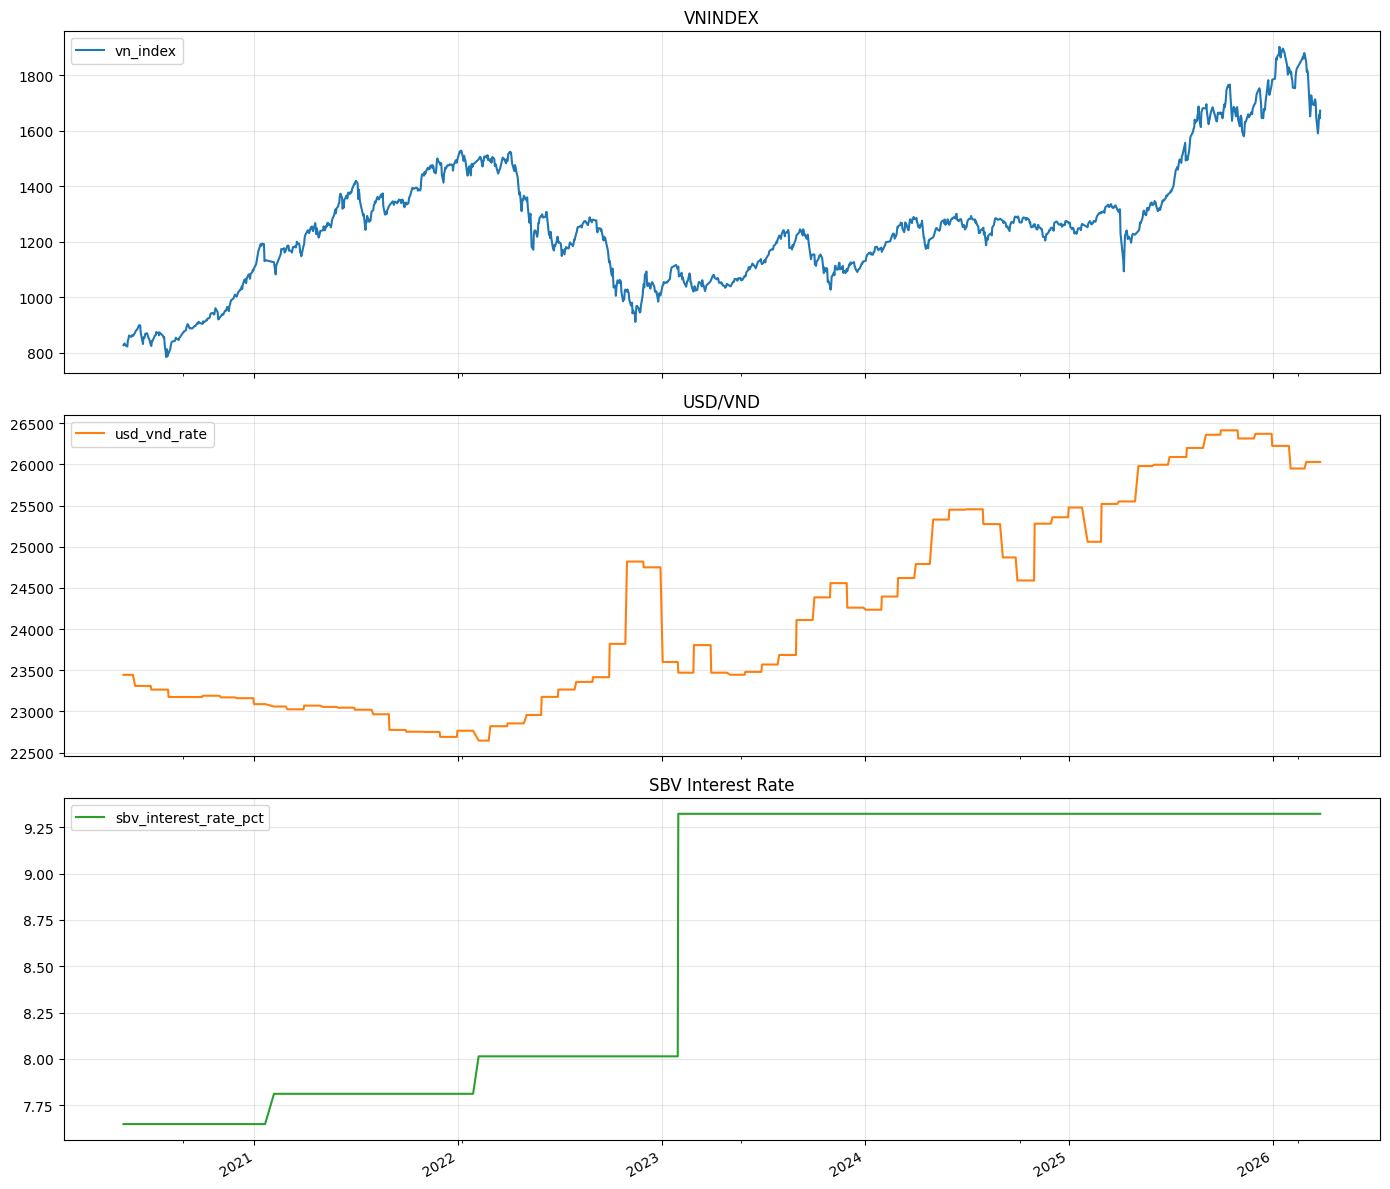

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

df.plot(x="date", y="vn_index", ax=axes[0], color="tab:blue", title="VNINDEX")
df.plot(x="date", y="usd_vnd_rate", ax=axes[1], color="tab:orange", title="USD/VND")
df.plot(x="date", y="sbv_interest_rate_pct", ax=axes[2], color="tab:green", title="SBV Interest Rate")

for ax in axes:
    ax.grid(alpha=0.3)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

,horizon,auc,brier,precision_high_risk,usable_rows
0,1w,0.653045,0.212300,NaN,1387
1,2w,0.695938,0.175262,0.611111,1378
2,1m,0.722359,0.115741,1.000000,1367


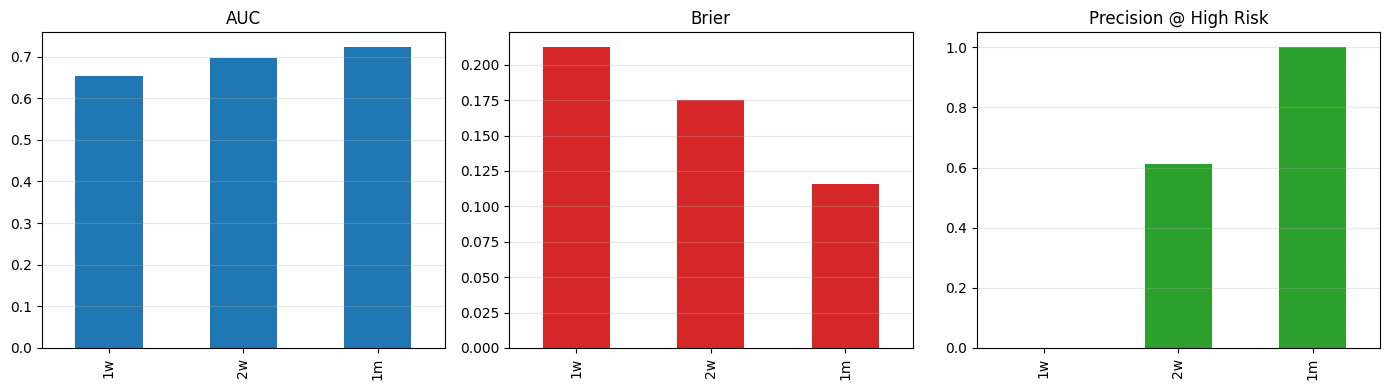

In [4]:
metrics_rows = []
for horizon in ["1w", "2w", "1m"]:
    metrics_rows.append(
        {
            "horizon": horizon,
            "auc": report["metrics"].get(f"auc_{horizon}"),
            "brier": report["metrics"].get(f"brier_{horizon}"),
            "precision_high_risk": report["metrics"].get(f"precision_high_risk_{horizon}"),
            "usable_rows": report["usable_rows"][horizon],
        }
    )
metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_df.plot(x="horizon", y="auc", kind="bar", ax=axes[0], legend=False, color="tab:blue", title="AUC")
metrics_df.plot(x="horizon", y="brier", kind="bar", ax=axes[1], legend=False, color="tab:red", title="Brier")
metrics_df.plot(x="horizon", y="precision_high_risk", kind="bar", ax=axes[2], legend=False, color="tab:green", title="Precision @ High Risk")
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Latest Quant Snapshot

,field,value
0,decision_score,0.260083
1,risk_regime,low
2,p_decline_1w,0.251534
3,p_decline_2w,0.349398
4,p_decline_1m,0.123016
5,expected_drawdown_pct,-0.964835
6,dominant_feature,usd_vnd_1m_change_pct


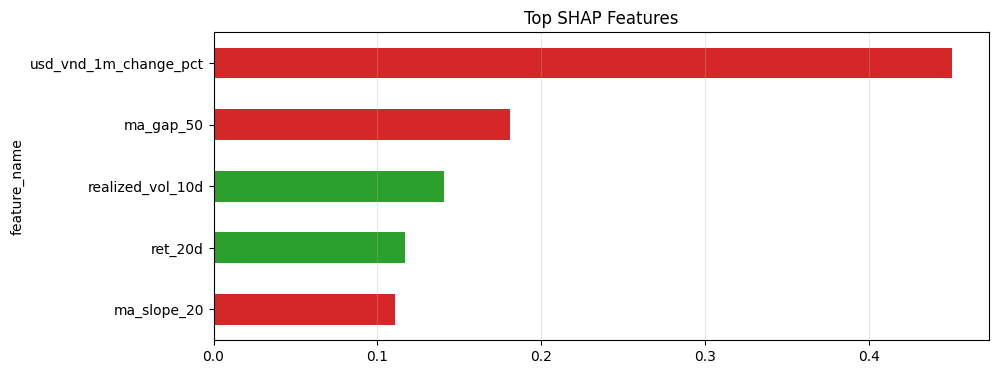

In [5]:
snapshot = report["quant_snapshot"]
display(Markdown("## Latest Quant Snapshot"))
display(pd.DataFrame(
    {
        "field": [
            "decision_score",
            "risk_regime",
            "p_decline_1w",
            "p_decline_2w",
            "p_decline_1m",
            "expected_drawdown_pct",
            "dominant_feature",
        ],
        "value": [
            snapshot["decision_score"],
            snapshot["risk_regime"],
            snapshot["horizons"]["p_decline_1w"],
            snapshot["horizons"]["p_decline_2w"],
            snapshot["horizons"]["p_decline_1m"],
            snapshot["horizons"]["expected_drawdown_pct"],
            snapshot["dominant_feature"],
        ],
    }
))

shap_df = pd.DataFrame(snapshot["shap_top"])
shap_df = shap_df.sort_values("share")
shap_colors = shap_df["direction"].map({"increases_risk": "tab:red", "decreases_risk": "tab:green"})
ax = shap_df.plot.barh(x="feature_name", y="share", color=shap_colors, figsize=(10, 4), legend=False, title="Top SHAP Features")
ax.grid(axis="x", alpha=0.3)
plt.show()

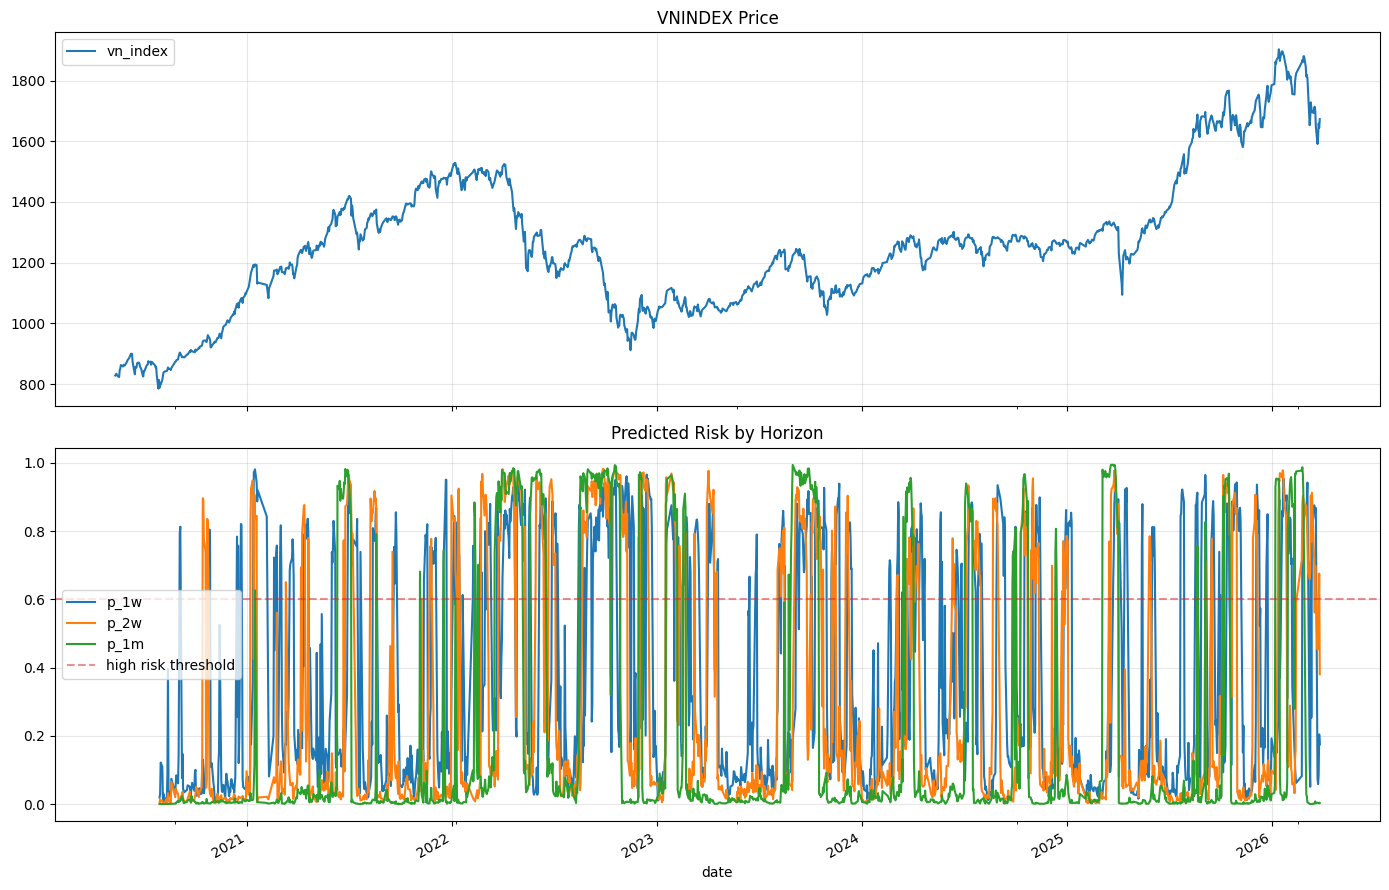

,date,vn_index,p_1w,p_2w,p_1m,decision_score
1427,2026-03-16,1693.21,0.843098,0.768223,0.001036,0.648479
1428,2026-03-17,1710.29,0.875630,0.718893,0.002430,0.646132
1429,2026-03-18,1713.83,0.867363,0.561146,0.002074,0.58713
1430,2026-03-19,1699.13,0.855711,0.698016,0.007939,0.630963
1431,2026-03-20,1647.81,0.867596,0.609788,0.002363,0.604317
1432,2026-03-23,1591.17,0.075078,0.452663,0.003978,0.193013
1433,2026-03-24,1614.77,0.058549,0.534532,0.003427,0.214118
1434,2026-03-25,1658.19,0.084834,0.557624,0.003047,0.233953
1435,2026-03-26,1644.63,0.204273,0.675710,0.002172,0.328856
1436,2026-03-27,1672.80,0.175008,0.380536,0.003390,0.212619


,date,label_available_1w,label_available_2w,label_available_1m
1427,2026-03-16,True,False,False
1428,2026-03-17,True,False,False
1429,2026-03-18,True,False,False
1430,2026-03-19,True,False,False
1431,2026-03-20,True,False,False
1432,2026-03-23,True,False,False
1433,2026-03-24,True,False,False
1434,2026-03-25,True,False,False
1435,2026-03-26,True,False,False
1436,2026-03-27,False,False,False


In [6]:
scored = feat.copy()

for horizon, spec in HORIZON_SPECS.items():
    horizon_features = trained.feature_names_by_horizon.get(horizon, FEATURE_COLS)
    feature_mask = scored[horizon_features].notna().all(axis=1)

    # Dự báo cho mọi dòng có đủ feature; label chỉ cần khi backtest/evaluation.
    proba = pd.Series(index=scored.index, dtype=float)
    proba.loc[feature_mask] = trained.estimators[horizon].predict_proba(scored.loc[feature_mask, horizon_features])[:, 1]
    scored[f"p_{horizon}"] = proba
    scored[f"label_available_{horizon}"] = scored[spec.label_col].notna()

scored["decision_score"] = scored[["p_1w", "p_2w", "p_1m"]].apply(
    lambda row: build_decision_score({"1w": row["p_1w"], "2w": row["p_2w"], "1m": row["p_1m"]}) if row.notna().all() else pd.NA,
    axis=1,
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
scored.plot(x="date", y="vn_index", ax=axes[0], color="tab:blue", title="VNINDEX Price")
scored.plot(x="date", y=["p_1w", "p_2w", "p_1m", "decision_score"], ax=axes[1], title="Predicted Risk by Horizon")
axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)
axes[1].axhline(0.6, color="tab:red", linestyle="--", alpha=0.5, label="high risk threshold")
axes[1].legend()
plt.tight_layout()
plt.show()

display(scored[["date", "vn_index", "p_1w", "p_2w", "p_1m", "decision_score"]].tail(10))
display(scored[["date", "label_available_1w", "label_available_2w", "label_available_1m"]].tail(10))